### Loading the SVHN Dataset

First, let's load the Street View House Numbers (SVHN) dataset using `torchvision.datasets`. This will download the dataset if it's not already present and prepare it for use.

In [1]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Define a transformation to convert images to tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load the training dataset
train_dataset_svhn = torchvision.datasets.SVHN(
    root='./data_svhn',
    split='train',
    download=True,
    transform=transform
)

# Load the test dataset
test_dataset_svhn = torchvision.datasets.SVHN(
    root='./data_svhn',
    split='test',
    download=True,
    transform=transform
)

print(f"SVHN Training dataset size: {len(train_dataset_svhn)}")
print(f"SVHN Test dataset size: {len(test_dataset_svhn)}")

100%|██████████| 182M/182M [00:06<00:00, 26.5MB/s]
100%|██████████| 64.3M/64.3M [00:13<00:00, 4.86MB/s]


SVHN Training dataset size: 73257
SVHN Test dataset size: 26032


Now that we have loaded the datasets, let's create DataLoaders to easily iterate over batches of data during training and evaluation.

In [2]:
batch_size = 64

train_loader_svhn = DataLoader(train_dataset_svhn, batch_size=batch_size, shuffle=True)
test_loader_svhn = DataLoader(test_dataset_svhn, batch_size=batch_size, shuffle=False)

print(f"Number of batches in SVHN training loader: {len(train_loader_svhn)}")
print(f"Number of batches in SVHN test loader: {len(test_loader_svhn)}")

Number of batches in SVHN training loader: 1145
Number of batches in SVHN test loader: 407


Let's visualize a few images from the SVHN dataset to get a better understanding of the data.

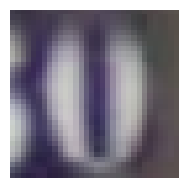

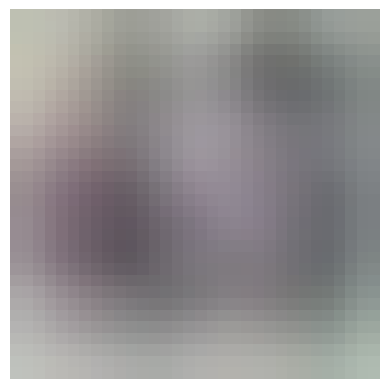

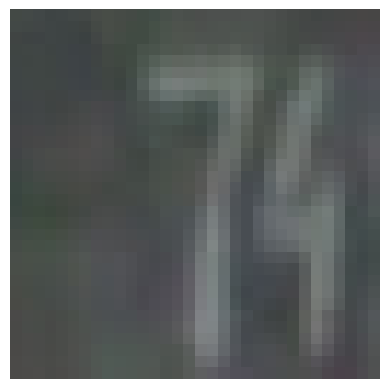

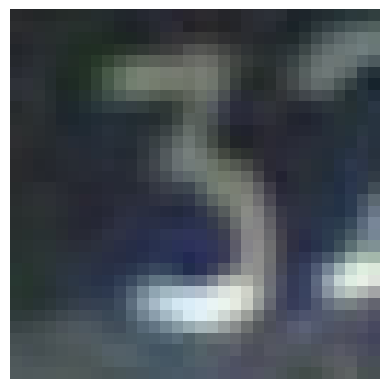

<Figure size 640x480 with 0 Axes>

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Function to show an image
def imshow(img, title=None):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Get some random training images
dataiter = iter(train_loader_svhn)
images, labels = next(dataiter)

# Show 4 images from the batch
fig = plt.figure(figsize=(10, 2.5))
for i in range(4):
    ax = fig.add_subplot(1, 4, i + 1, xticks=[], yticks=[])
    imshow(images[i])
    ax.set_title(str(labels[i].item()))
plt.suptitle('Sample SVHN Images', y=1.02)
plt.show()

### Define the Convolutional Neural Network (CNN) Model

Now, let's define a simple CNN architecture for classifying the SVHN digits. This model will take 32x32 color images as input.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Check for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Input channels 3 for RGB, output channels 32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)
        # After two pooling layers, image size will be 32/4 = 8, so 64 * 8 * 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes for digits 0-9

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(-1, 64 * 8 * 8) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
print(model)


Using device: cpu
SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


### Training and Evaluation Functions

Next, we'll define the training and testing loops. We'll use CrossEntropyLoss as our loss function and Adam optimizer for training.

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, criterion, optimizer, num_epochs=10):
    model.train() # Set the model to training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # Zero the parameter gradients

            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, labels) # Calculate loss
            loss.backward() # Backward pass
            optimizer.step() # Optimize weights

            running_loss += loss.item()
            if (i+1) % 100 == 0:    # print every 100 mini-batches
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {running_loss / 100:.4f}')
                running_loss = 0.0
    print('Finished Training')

def evaluate_model(model, test_loader):
    model.eval() # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation during evaluation
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'Accuracy of the network on the test images: {accuracy:.2f}%')
    return accuracy


### Train and Evaluate the Model on SVHN

Now, let's train our `SimpleCNN` model on the SVHN training dataset and then evaluate its performance on the SVHN test dataset.

In [6]:
print("\n--- Training SVHN Model ---")
train_model(model, train_loader_svhn, criterion, optimizer, num_epochs=5) # You can adjust num_epochs

print("\n--- Evaluating SVHN Model ---")
svhn_accuracy = evaluate_model(model, test_loader_svhn)
print(f"SVHN Test Accuracy: {svhn_accuracy:.2f}%")



--- Training SVHN Model ---
Epoch [1/5], Step [100/1145], Loss: 2.2489
Epoch [1/5], Step [200/1145], Loss: 2.2432
Epoch [1/5], Step [300/1145], Loss: 2.2267
Epoch [1/5], Step [400/1145], Loss: 2.1755
Epoch [1/5], Step [500/1145], Loss: 1.9883
Epoch [1/5], Step [600/1145], Loss: 1.6178
Epoch [1/5], Step [700/1145], Loss: 1.2870
Epoch [1/5], Step [800/1145], Loss: 1.1000
Epoch [1/5], Step [900/1145], Loss: 1.0217
Epoch [1/5], Step [1000/1145], Loss: 0.9598
Epoch [1/5], Step [1100/1145], Loss: 0.8582
Epoch [2/5], Step [100/1145], Loss: 0.8263
Epoch [2/5], Step [200/1145], Loss: 0.8141
Epoch [2/5], Step [300/1145], Loss: 0.7885
Epoch [2/5], Step [400/1145], Loss: 0.7909
Epoch [2/5], Step [500/1145], Loss: 0.7604
Epoch [2/5], Step [600/1145], Loss: 0.7555
Epoch [2/5], Step [700/1145], Loss: 0.7297
Epoch [2/5], Step [800/1145], Loss: 0.7012
Epoch [2/5], Step [900/1145], Loss: 0.6988
Epoch [2/5], Step [1000/1145], Loss: 0.6806
Epoch [2/5], Step [1100/1145], Loss: 0.6741
Epoch [3/5], Step [10

### Loading the MNIST Dataset

Now, let's load the MNIST dataset to compare its performance with SVHN using a similar architecture. MNIST is a grayscale dataset, so we'll need to adjust our model's first convolutional layer accordingly.

In [7]:
# Load the training dataset for MNIST
train_dataset_mnist = torchvision.datasets.MNIST(
    root='./data_mnist',
    train=True,
    download=True,
    transform=transform # Using the same ToTensor transform
)

# Load the test dataset for MNIST
test_dataset_mnist = torchvision.datasets.MNIST(
    root='./data_mnist',
    train=False,
    download=True,
    transform=transform
)

print(f"MNIST Training dataset size: {len(train_dataset_mnist)}")
print(f"MNIST Test dataset size: {len(test_dataset_mnist)}")

# Create DataLoaders for MNIST
train_loader_mnist = DataLoader(train_dataset_mnist, batch_size=batch_size, shuffle=True)
test_loader_mnist = DataLoader(test_dataset_mnist, batch_size=batch_size, shuffle=False)

print(f"Number of batches in MNIST training loader: {len(train_loader_mnist)}")
print(f"Number of batches in MNIST test loader: {len(test_loader_mnist)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 608kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]

MNIST Training dataset size: 60000
MNIST Test dataset size: 10000
Number of batches in MNIST training loader: 938
Number of batches in MNIST test loader: 157


### Define and Train the CNN Model for MNIST

We will use an adapted version of our `SimpleCNN` model for MNIST. The primary change will be in the first convolutional layer to accommodate the single-channel (grayscale) input of MNIST images, as opposed to the 3-channel (RGB) input for SVHN.

In [8]:
class SimpleCNN_MNIST(nn.Module):
    def __init__(self):
        super(SimpleCNN_MNIST, self).__init__()
        # Input channels 1 for grayscale MNIST, output channels 32
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.25)
        # For MNIST (28x28 images), after two pooling layers (each halves size):
        # 28 / 2 = 14, then 14 / 2 = 7. So, 64 * 7 * 7.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 classes for digits 0-9

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.dropout(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(-1, 64 * 7 * 7) # Flatten the tensor
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_mnist = SimpleCNN_MNIST().to(device)
print(model_mnist)

criterion_mnist = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(model_mnist.parameters(), lr=0.001)

print("\n--- Training MNIST Model ---")
train_model(model_mnist, train_loader_mnist, criterion_mnist, optimizer_mnist, num_epochs=5)

print("\n--- Evaluating MNIST Model ---")
mnist_accuracy = evaluate_model(model_mnist, test_loader_mnist)
print(f"MNIST Test Accuracy: {mnist_accuracy:.2f}%")

SimpleCNN_MNIST(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

--- Training MNIST Model ---
Epoch [1/5], Step [100/938], Loss: 0.9068
Epoch [1/5], Step [200/938], Loss: 0.3149
Epoch [1/5], Step [300/938], Loss: 0.2075
Epoch [1/5], Step [400/938], Loss: 0.1686
Epoch [1/5], Step [500/938], Loss: 0.1540
Epoch [1/5], Step [600/938], Loss: 0.1350
Epoch [1/5], Step [700/938], Loss: 0.1252
Epoch [1/5], Step [800/938], Loss: 0.1164
Epoch [1/5], Step [900/938], Loss: 0.1072
Epoch [2/5], Step [100/938], Loss: 0.0993
Epoch [2/5], Step [200/938], Loss: 0.1013
Epoch [2/5], Step [300/938], Loss: 0.0856
Epoch [2/5], Step [400/938], Loss: 0.0937

### Comparison of SVHN and MNIST Performance

Let's compare the final accuracies of the models trained on SVHN and MNIST.

In [9]:
print(f"\nSVHN Model Test Accuracy: {svhn_accuracy:.2f}%")
print(f"MNIST Model Test Accuracy: {mnist_accuracy:.2f}%")

if mnist_accuracy > svhn_accuracy:
    print("\nAs expected, the model performed better on MNIST than on SVHN.")
else:
    print("\nThe model performed better on SVHN than on MNIST.")

print("\nThis difference in performance highlights the increased complexity and real-world challenges present in the SVHN dataset compared to the simpler, more controlled MNIST digits.")


SVHN Model Test Accuracy: 86.78%
MNIST Model Test Accuracy: 98.91%

As expected, the model performed better on MNIST than on SVHN.

This difference in performance highlights the increased complexity and real-world challenges present in the SVHN dataset compared to the simpler, more controlled MNIST digits.


### Save the Trained MNIST Model

Let's save the state dictionary of our trained `model_mnist` so we can load it later without retraining.

In [10]:
model_save_path = './mnist_cnn_model.pth'
torch.save(model_mnist.state_dict(), model_save_path)
print(f"MNIST model saved to {model_save_path}")

MNIST model saved to ./mnist_cnn_model.pth


### Guardar el Modelo SVHN Entrenado

Ahora, guardemos el estado de nuestro modelo de SVHN entrenado para poder cargarlo más tarde sin necesidad de volver a entrenarlo.

In [15]:
svhn_model_save_path = './svhn_cnn_model.pth'
torch.save(model.state_dict(), svhn_model_save_path)
print(f"Modelo SVHN guardado en {svhn_model_save_path}")

Modelo SVHN guardado en ./svhn_cnn_model.pth


### Probar el Modelo de MNIST con una Imagen Subida por el Usuario

Ahora, implementemos una funcionalidad para que puedas subir tu propia imagen de un dígito y ver la predicción de nuestro modelo de MNIST entrenado.

Por favor, sube una imagen de un dígito (preferiblemente en blanco y negro con fondo blanco y el dígito en negro).


Saving 7 numero.png to 7 numero (1).png
User uploaded file "7 numero (1).png"


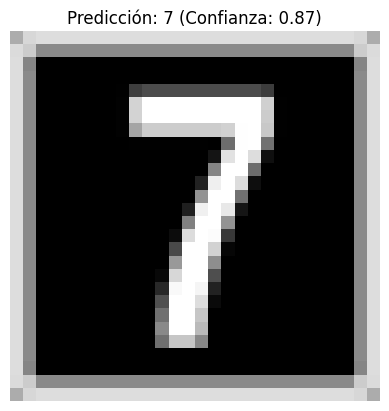

In [14]:
from google.colab import files
from PIL import Image, ImageOps
import io

def predict_uploaded_image(model, transform):
    uploaded = files.upload()

    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')

        # Load image from bytes
        img = Image.open(io.BytesIO(uploaded[fn]))

        # Convert to grayscale and resize for MNIST (28x28)
        img = img.convert('L') # 'L' mode is grayscale
        img = img.resize((28, 28))

        # Invert colors: MNIST models are typically trained on white digits on black background
        # If the user uploads black digit on white background, this will correct it.
        img = ImageOps.invert(img)

        # Apply the same transformation used for the dataset
        # ToTensor() converts PIL Image to FloatTensor (C, H, W) and scales to [0,1]
        input_tensor = transform(img)

        # Add a batch dimension: (C, H, W) -> (1, C, H, W)
        input_batch = input_tensor.unsqueeze(0).to(device)

        # Make prediction
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            output = model(input_batch)
            probabilities = F.softmax(output, dim=1)
            predicted_class = torch.argmax(probabilities, dim=1).item()
            confidence = probabilities[0][predicted_class].item()

        # Display the image and prediction
        plt.imshow(img, cmap='gray')
        plt.title(f"Predicción: {predicted_class} (Confianza: {confidence:.2f})")
        plt.axis('off')
        plt.show()

# Call the function to predict on an uploaded image
print("Por favor, sube una imagen de un dígito (preferiblemente en blanco y negro con fondo blanco y el dígito en negro).")
predict_uploaded_image(loaded_model_mnist, transforms.ToTensor())

### Probar el Modelo de SVHN con una Imagen Subida por el Usuario

Ahora, implementemos una funcionalidad similar para que puedas subir tu propia imagen de un dígito y ver la predicción de nuestro modelo de SVHN entrenado. Ten en cuenta que el modelo de SVHN fue entrenado con imágenes a color (3 canales) de 32x32 píxeles, así que las imágenes que subas serán redimensionadas y convertidas para coincidir con este formato.

Por favor, sube una imagen de un dígito de SVHN (a color, de calle o matrícula, preferiblemente).


Saving svnh.png to svnh.png
User uploaded file "svnh.png"


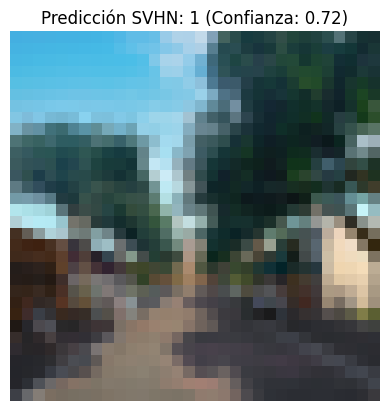

In [13]:
from google.colab import files
from PIL import Image
import io
import torchvision.transforms as transforms

def predict_uploaded_image_svhn(model, transform_svhn):
    uploaded = files.upload()

    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')

        # Load image from bytes
        img = Image.open(io.BytesIO(uploaded[fn]))

        # Resize for SVHN (32x32) and ensure RGB (3 channels)
        img = img.resize((32, 32)).convert('RGB')

        # Apply the same transformation used for the dataset
        # ToTensor() converts PIL Image to FloatTensor (C, H, W) and scales to [0,1]
        input_tensor = transform_svhn(img)

        # Add a batch dimension: (C, H, W) -> (1, C, H, W)
        input_batch = input_tensor.unsqueeze(0).to(device)

        # Make prediction
        model.eval() # Set model to evaluation mode
        with torch.no_grad():
            output = model(input_batch)
            probabilities = F.softmax(output, dim=1)
            predicted_class = torch.argmax(probabilities, dim=1).item()
            confidence = probabilities[0][predicted_class].item()

        # Display the image and prediction
        plt.imshow(np.transpose(input_tensor.cpu().numpy(), (1, 2, 0))) # Display tensor image
        plt.title(f"Predicción SVHN: {predicted_class} (Confianza: {confidence:.2f})")
        plt.axis('off')
        plt.show()

# Define a specific transform for SVHN prediction (ToTensor)
# The original 'transform' was already ToTensor, so we can reuse it or define explicitly
transform_svhn_predict = transforms.Compose([
    transforms.ToTensor()
])

# Call the function to predict on an uploaded image for SVHN
print("Por favor, sube una imagen de un dígito de SVHN (a color, de calle o matrícula, preferiblemente).")
predict_uploaded_image_svhn(model, transform_svhn_predict)
